#**Heart Attack Dataset**

#Loading Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from scipy.stats import chi2_contingency

#Loading the Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Heart Attack.csv")
df

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


#First 10 rows




In [4]:
df.head(10)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
5,58,0,61,112,58,87.0,1.83,0.004,negative
6,32,0,40,179,68,102.0,0.71,0.003,negative
7,63,1,60,214,82,87.0,300.00,2.370,positive
8,44,0,60,154,81,135.0,2.35,0.004,negative
9,67,1,61,160,95,100.0,2.84,0.011,negative


#Last 10 rows

In [5]:
df.tail(10)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
1309,47,1,94,105,81,135.0,36.24,0.263,positive
1310,70,0,80,135,75,351.0,2.21,10.000,positive
1311,85,1,112,115,69,114.0,2.19,0.062,positive
1312,48,1,84,118,68,96.0,5.33,0.006,negative
1313,86,0,40,179,68,147.0,5.22,0.011,negative
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive
1318,51,1,94,157,79,134.0,50.89,1.770,positive


#Random Sample/Row

In [6]:
df.sample()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
1084,65,1,70,117,61,84.0,1.58,0.397,positive


#Basic Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [8]:
df.shape

(1319, 9)

In [9]:
df.dtypes

,0
age,int64
gender,int64
impluse,int64
pressurehight,int64
pressurelow,int64
glucose,float64
kcm,float64
troponin,float64
class,object


#Positive-Negative Count (isBalanced)

In [10]:
df.gender.value_counts()            #1 is male and 0 is female

,count
gender,
1,870
0,449


In [11]:
df.age.value_counts()

,count
age,
60,106
70,73
50,68
63,64
65,62
...,...
91,1
100,1
88,1


In [12]:
df.groupby(["gender", "class"]).size()

gender  class   
0       negative    202
        positive    247
1       negative    307
        positive    563
dtype: int64

In [13]:
class_percent = df['class'].value_counts(normalize=True) * 100
print("\nPercentages: \n")
print(class_percent)


Percentages: 

class
positive    61.410159
negative    38.589841
Name: proportion, dtype: float64


#Positive-Negetive Visualization

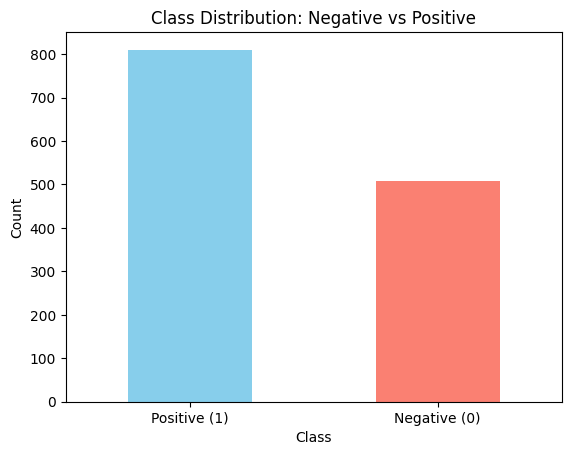

In [14]:
df['class'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution: Negative vs Positive')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['Positive (1)', 'Negative (0)'], rotation=0)
plt.show()

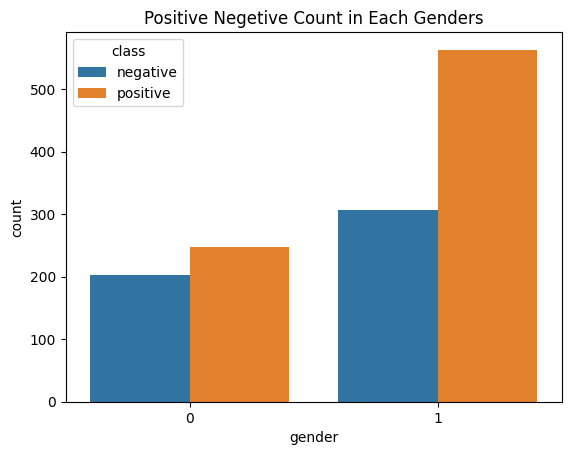

In [15]:
sns.countplot(x='gender', hue='class', data=df)
plt.title("Positive Negetive Count in Each Genders")
plt.show()


#Positive Negative Percentage (Pie Chart)

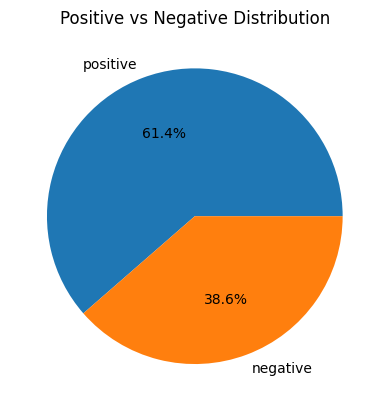

In [16]:
class_counts = df['class'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
plt.title("Positive vs Negative Distribution")
plt.show()

#Handling Missing Data

In [17]:
df.isnull()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1314,False,False,False,False,False,False,False,False,False
1315,False,False,False,False,False,False,False,False,False
1316,False,False,False,False,False,False,False,False,False
1317,False,False,False,False,False,False,False,False,False


In [18]:
df.isnull().sum()


,0
age,0
gender,0
impluse,0
pressurehight,0
pressurelow,0
glucose,0
kcm,0
troponin,0
class,0


#Statistical Summary

In [19]:
df.describe()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [20]:
df.describe(include="all")

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,positive
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,810
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942,NaN
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568,NaN
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000,NaN
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000,NaN
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000,NaN
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500,NaN


#Encoding Categorical Data (Label Encoding)

In [21]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# OR df['class'] = df['class'].map({'negative': 0, 'positive': 1})

In [22]:
df.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0


In [23]:
df_copy = df
df_copy

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


#MEAN

In [24]:
mean_values = df.mean(numeric_only=True)
mean_values

,0
age,56.191812
gender,0.659591
impluse,78.336619
pressurehight,127.170584
pressurelow,72.269143
glucose,146.634344
kcm,15.274306
troponin,0.360942
class,0.614102


In [25]:
mean_values = df.groupby("class").mean(numeric_only=True)
mean_values

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
class,,,,,,,,
0,52.094303,0.603143,77.886051,127.856582,72.440079,149.757760,2.555344,0.026988
1,58.766667,0.695062,78.619753,126.739506,72.161728,144.671605,23.266838,0.570798


#MEDIAN

In [26]:
median_values = df.median(numeric_only=True)
median_values

,0
age,58.000
gender,1.000
impluse,74.000
pressurehight,124.000
pressurelow,72.000
glucose,116.000
kcm,2.850
troponin,0.014
class,1.000


In [27]:
median_values = df.groupby("class").median(numeric_only=True)
median_values

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
class,,,,,,,,
0,52.0,1.0,75.0,125.0,72.0,117.0,2.310,0.006
1,60.0,1.0,74.0,122.0,71.0,116.0,3.775,0.044


#MODE

In [28]:
mode_values = df.mode(numeric_only=True).iloc[0]
mode_values

,0
age,60.000
gender,1.000
impluse,60.000
pressurehight,150.000
pressurelow,75.000
glucose,100.000
kcm,300.000
troponin,0.003
class,1.000


In [29]:
mode_values = df.groupby("class").agg(lambda x: x.mode()[0])
mode_values

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
class,,,,,,,,
0,60,1,60,150,75,98.0,1.6,0.003
1,60,1,60,150,75,100.0,300.0,0.003


#Outliers (Box Plot)

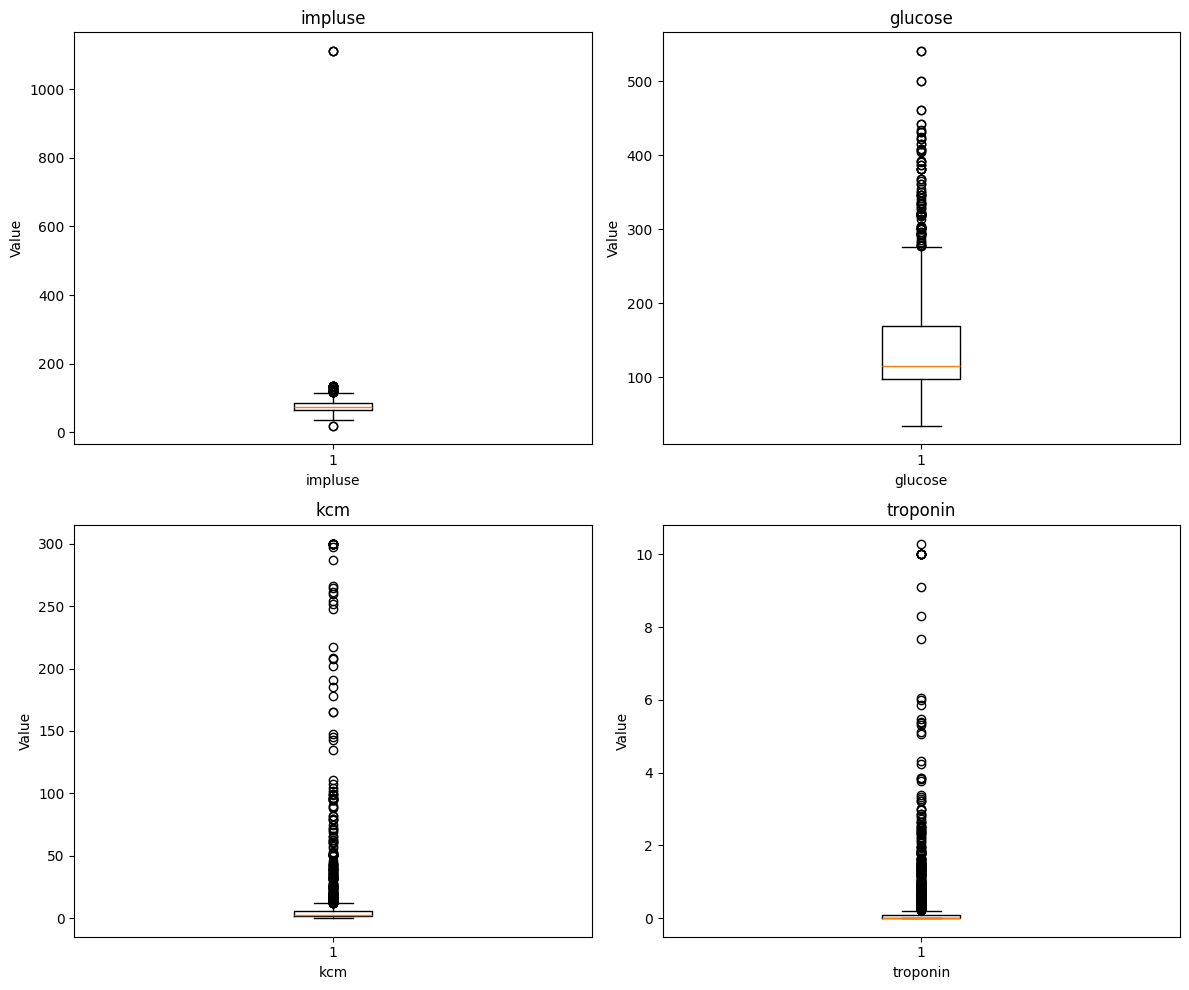

In [30]:
cols = ["impluse", "glucose", "kcm", "troponin"]

plt.figure(figsize=(12, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[col].dropna())
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()


/tmp/ipython-input-2752932429.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cols)


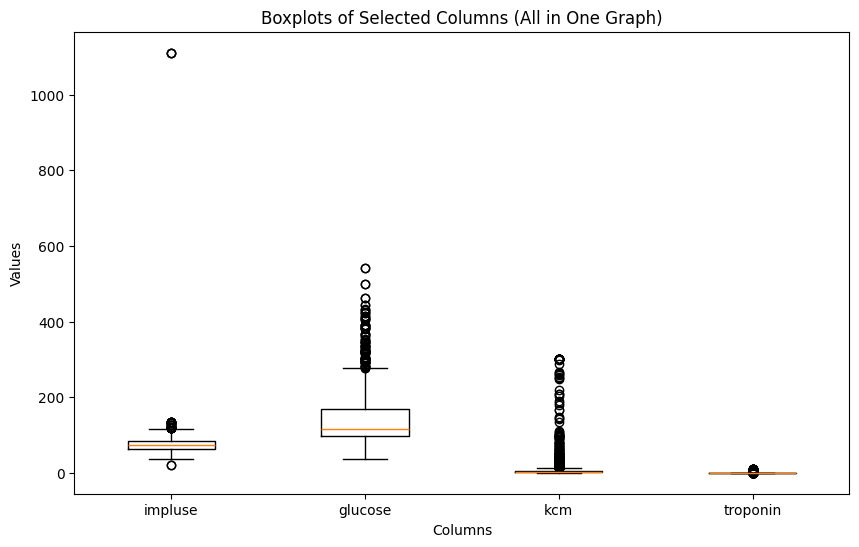

In [31]:
cols = ["impluse", "glucose", "kcm", "troponin"]

# Prepare data as a list of series
data = [df[col].dropna() for col in cols]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=cols)
plt.title("Boxplots of Selected Columns (All in One Graph)")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()

#Outlier Removal

In [32]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

df_clean = remove_outliers_iqr(df, numeric_cols)

print("Original dataset shape:", df.shape)
print("Dataset shape after removing outliers:", df_clean.shape)

df_clean.head()

Original dataset shape: (1319, 9)
Dataset shape after removing outliers: (788, 9)


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,0
2,55,1,64,160,77,270.0,1.99,0.003,0
5,58,0,61,112,58,87.0,1.83,0.004,0
6,32,0,40,179,68,102.0,0.71,0.003,0
8,44,0,60,154,81,135.0,2.35,0.004,0


Since the reduction to dataset is too significant (531 rows removed), we will not remove the outliers.

#Feature Selection

In [33]:
print(df.columns.tolist())              #Column names

['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin', 'class']


In [34]:
x = df.drop("class", axis=1)
x

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
0,64,1,66,160,83,160.0,1.80,0.012
1,21,1,94,98,46,296.0,6.75,1.060
2,55,1,64,160,77,270.0,1.99,0.003
3,64,1,70,120,55,270.0,13.87,0.122
4,55,1,64,112,65,300.0,1.08,0.003
...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006
1315,66,1,84,125,55,149.0,1.33,0.172
1316,45,1,85,168,104,96.0,1.24,4.250
1317,54,1,58,117,68,443.0,5.80,0.359


In [35]:
y = df["class"]
y

,class
0,0
1,1
2,0
3,1
4,0
...,...
1314,0
1315,1
1316,1
1317,1


In [36]:
print(x.shape, y.shape)

(1319, 8) (1319,)


#ML Model

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_pred

(1055, 8) (264, 8)


array([1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0])

#Model's Performance

In [38]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7954545454545454


In [39]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.8187134502923976


In [40]:
# Detailed report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.69      0.72       101
           1       0.82      0.86      0.84       163

    accuracy                           0.80       264
   macro avg       0.79      0.78      0.78       264
weighted avg       0.79      0.80      0.79       264



#Vizualization

#Confusion Matrix

In [41]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (numeric):")
print(cm)

Confusion Matrix (numeric):
[[ 70  31]
 [ 23 140]]


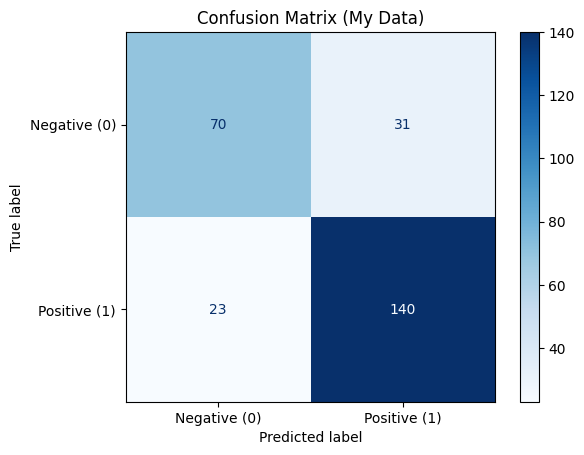

In [42]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Positive (1)'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix (My Data)')
plt.show()


#Class Distribution

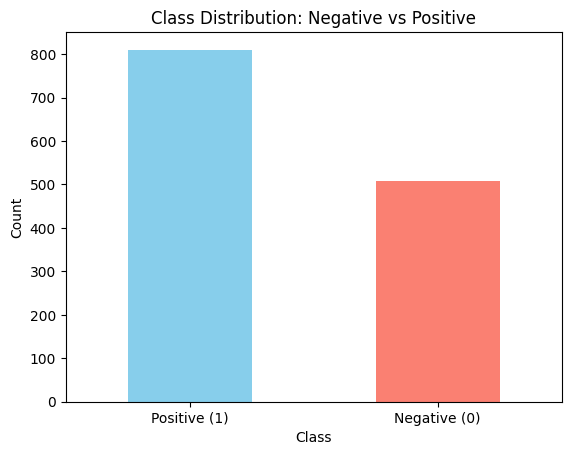

In [43]:
df['class'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution: Negative vs Positive')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['Positive (1)', 'Negative (0)'], rotation=0)
plt.show()

#Histogram

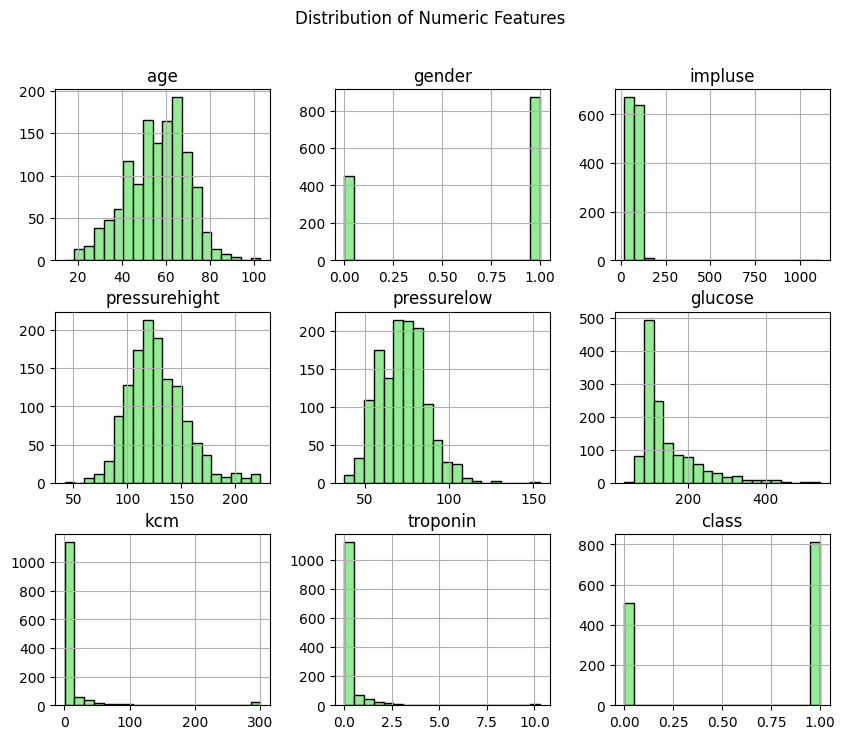

In [44]:
df.hist(figsize=(10,8), bins=20, color='lightgreen', edgecolor='black')
plt.suptitle('Distribution of Numeric Features')
plt.show()

#Heart Attack Outcome of Each Gender

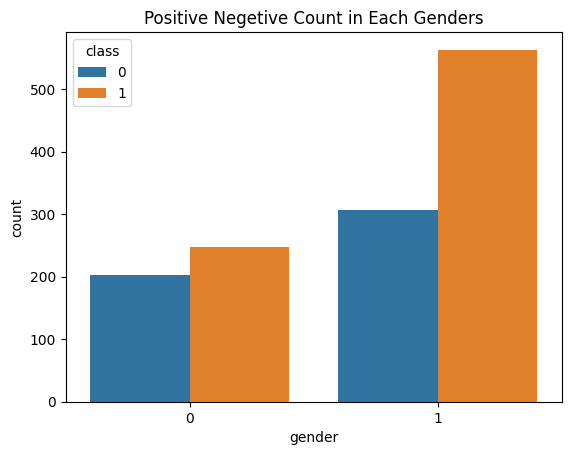

In [45]:
sns.countplot(x='gender', hue='class', data=df)
plt.title("Positive Negetive Count in Each Genders")
plt.show()


#Correlation

#Correlation Matrix

In [46]:
print("=== Correlation Matrix ===")
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

=== Correlation Matrix ===
                    age    gender   impluse  pressurehight  pressurelow  \
age            1.000000 -0.092874 -0.023440       0.017441     0.002614   
gender        -0.092874  1.000000 -0.026781       0.011065    -0.009370   
impluse       -0.023440 -0.026781  1.000000       0.010882     0.108353   
pressurehight  0.017441  0.011065  0.010882       1.000000     0.586166   
pressurelow    0.002614 -0.009370  0.108353       0.586166     1.000000   
glucose       -0.004193  0.006668 -0.019584       0.020807    -0.025614   
kcm            0.018419  0.017527 -0.013001      -0.016396    -0.023403   
troponin       0.088800  0.065793  0.011180       0.043729     0.043360   
class          0.238097  0.094432  0.006920      -0.020825    -0.009659   

                glucose       kcm  troponin     class  
age           -0.004193  0.018419  0.088800  0.238097  
gender         0.006668  0.017527  0.065793  0.094432  
impluse       -0.019584 -0.013001  0.011180  0.006920 

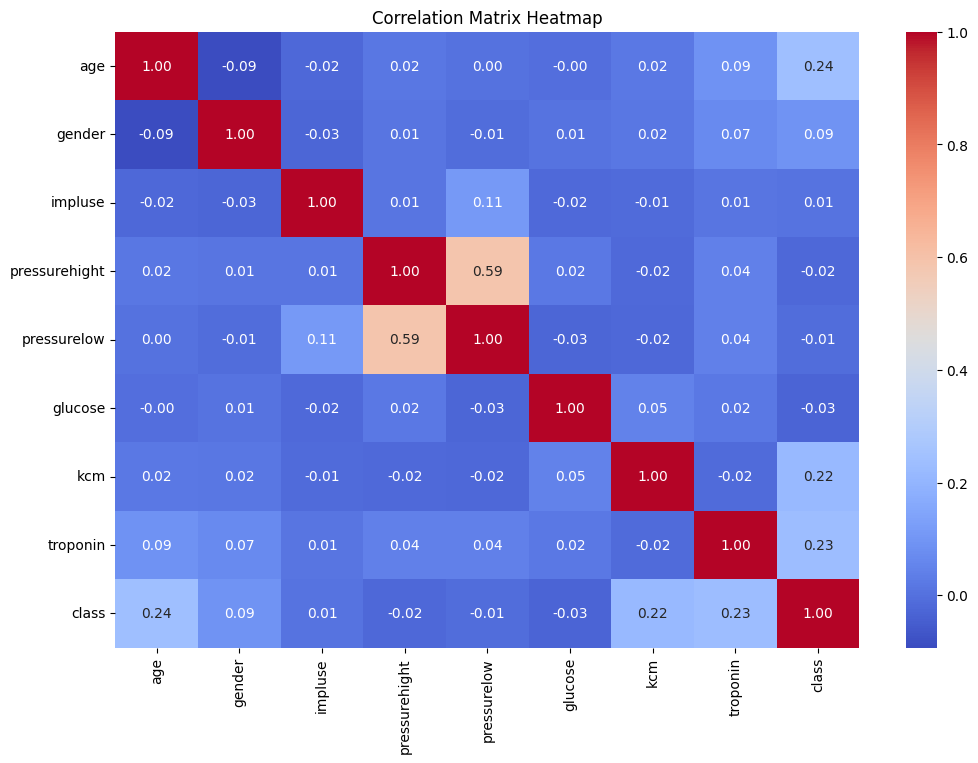

In [47]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()


#Chi Square Test and P Value

In [48]:
df_cat = df.copy()

target = 'class'

print("Chi-Square Test Results:\n")

for col in df_cat.select_dtypes(include=['int64']).columns:
    if col == target:
        continue

    contingency = pd.crosstab(df_cat[col], df_cat[target])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f"Feature: {col}")
    print(f"Chi-square: {chi2:.4f}")
    print(f"P-value: {p:.4f}\n")


Chi-Square Test Results:

Feature: age
Chi-square: 151.9742
P-value: 0.0000

Feature: gender
Chi-square: 11.3563
P-value: 0.0008

Feature: impluse
Chi-square: 78.9784
P-value: 0.4477

Feature: pressurehight
Chi-square: 128.6250
P-value: 0.1817

Feature: pressurelow
Chi-square: 72.6416
P-value: 0.4567

